# GERADOR SINTÉTICO DE MARLIM
Calibração e geração do dataset sintético que imita o bloco de Marlim.

Fluxo: `Generator.ipynb` → `../Dataset/marlim_opt/Format.ipynb` → treino (`../Model/Analysis.ipynb`)
→ `Predict.ipynb` → comparação no `Analysis.ipynb`.

In [1]:
import os, re, json, time, shutil
from math import floor
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
import scipy.ndimage as ndi
from tqdm import tqdm

import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

zscore = lambda a: (a - a.mean()) / (a.std() + 1e-8)

In [2]:
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    print('random seed done')


seed_everything(42)

random seed done


In [3]:
PATCH_METADATA = 'files/patch_metadata.json'
CACHE_DIR      = 'files/cache'
PATCH_IDS      = ['1200', '1300', '1400', '2600']
MARLIM_DIR     = '../Dataset/marlim'
DATASET_DIR    = '../Dataset/marlim_opt/original'

# BLOCO REAL (REFERÊNCIA)
Medições feitas nos patches 1200/1300/1400/2600 que calibram o gerador:

* **coluna vertical**: água até z≈250 → pacote raso forte 250–600 (std≈0.17) → intervalo
  fraco 600–800 (≈0.10) → banda brilhante dobrada 800–1200 (0.15–0.20) → zona morta >1200 (≈0.02);
* **espectro vertical por janela z** (pico em ciclos/voxel, média das 4 seções):
  0.23 (z250) → 0.14 (z400) → 0.10 (z550) → 0.055 (z700) → ~0.04 (z850–1300).
  Os `freqKnots` são calibrados para reproduzir esses picos na **saída** — o pipeline
  (camadas 1–3 px, blur) atenua as altas, então o knot nominal fica acima da freq. efetiva.
  Conferir com `validateSpectra(SECTIONS)` após qualquer mudança;
* **falhas do especialista** (88 nas 4 seções): dip p5/p50/p95 = 48/66/78°, comprimento
  mediano 348 px, **83% > 128 px** (atravessam um tile inteiro), famílias dominó com
  conjugadas ocasionais;
* **estatística por região** (crops 128², slab normalizado em [0,1]): μ≈0.50 em todas;
  σ mediano: raso 0.17, transição 0.09, brilhante 0.21, morto 0.02, fundo do mar 0.14.
  O sintético deve cair nessas faixas **após o Format** — conferir com `validateRegions(SECTIONS)`.

In [4]:
class MarlimBlock:
    """Reconstrói o slab (64, 1601, 2240) a partir dos patch_*.dat (com overlap)."""

    def __init__(self, metadata_path=PATCH_METADATA):
        self.meta  = json.load(open(metadata_path))
        self.ps    = self.meta['patch_size']
        self.ov    = self.meta['overlap_voxels']
        self.shape = tuple(self.meta['original_shape'])

    def reconstruct(self, path, desc='montando'):
        """Monta o volume colando o miolo de cada patch (descarta as bordas de overlap)."""
        ps, ov  = self.ps, self.ov
        stride  = ps - 2 * ov
        lastIdx = [floor(n / stride) for n in self.shape]
        vol     = np.zeros(self.shape, np.float32)

        for fname in tqdm(sorted(os.listdir(path)), desc=desc):
            m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', fname)
            if not m:
                continue

            # origem do patch no volume (o último de cada eixo encosta na borda)
            d, h, w = [max(0, size - stride) if idx == last else idx * stride
                       for idx, last, size in zip(map(int, m.groups()), lastIdx, self.shape)]

            core = np.fromfile(os.path.join(path, fname), np.float32).reshape((ps, ps, ps))
            core = core[ov:ps - ov, ov:ps - ov, ov:ps - ov]

            cd = min(core.shape[0], self.shape[0] - d)
            ch = min(core.shape[1], self.shape[1] - h)
            cw = min(core.shape[2], self.shape[2] - w)
            vol[d:d + cd, h:h + ch, w:w + cw] = core[:cd, :ch, :cw]
        return vol

    def center_section(self, pid, use_cache=True):
        """Seção (1601, 2240) da inline central do patch <pid>, com cache em disco."""
        os.makedirs(CACHE_DIR, exist_ok=True)
        cache = os.path.join(CACHE_DIR, f'real_center_{pid}.npy')

        if use_cache and os.path.exists(cache):
            return np.load(cache)

        vol = self.reconstruct(f'{MARLIM_DIR}/patches_{pid}', f'patches_{pid}')
        sec = vol[vol.shape[0] // 2].copy()
        del vol
        np.save(cache, sec)
        return sec


def load_sections(pids=PATCH_IDS):
    block = MarlimBlock()
    return {pid: block.center_section(pid) for pid in pids}


def load_interpretado(pid):
    """Máscara booleana (1601, 2240) da interpretação do especialista."""
    path = f'files/patches/{pid}/{pid}_interpretado.png'
    return np.array(Image.open(path).convert('L')) > 128

In [5]:
SECTIONS     = load_sections()
INTERPRETADO = {pid: load_interpretado(pid) for pid in PATCH_IDS}

# GERADOR SINTÉTICO
`MarlimSyntheticGenerator` — toda a construção do tile vive em métodos privados da
classe e o `get()` só encadeia o pipeline. O que ele faz diferente do gerador antigo:

* **coluna virtual 0–1600**: cada tile sorteia um topo `zv0` e os perfis de frequência,
  amplitude, dobra e crosshatch seguem a profundidade (wavelet não-estacionário);
* **campo Z único**: dobra + mergulho + drape do fundo + falhas por cisalhamento
  vertical, com uma só interpolação (~3.5 s/tile);
* **falhas dominó** que atravessam o tile: dip 58–84°, azimute 45°+k·90°±18°
  (nunca traço raso na seção), rejeito ~constante, conjugadas p=0.20;
* **ganho global** (sem z-score por tile): tiles fracos continuam fracos, como no real;
* **saturação simétrica em ±clipLevel** — o slab real foi saturado no próprio p01/p99,
  então o `format()` (o que o Format do dataset faz) vira o mapeamento exato
  [−clip, +clip] → [0,1], com μ≈0.5 e σ/min/max na faixa do real por região
  (`ampKnots` calibrados via `validateRegions`);
* **negativos duros**: água + fundo do mar (12%), zona morta com crosshatch, 14% sem falha.

`get(seed, zv0=...)` força a banda: 300≈raso, 620≈transição, 950≈brilhante, 1250≈morto.

In [6]:
class MarlimSyntheticGenerator:
    """Gera tiles (img, mask) 128³ que imitam o bloco de Marlim.

    Cada tile sorteia um topo zv0 na coluna virtual (0..1600 ≈ voxels reais) e os
    perfis (frequência, amplitude, crosshatch, dobra) seguem essa profundidade.
    Um único campo Z(x,y,z) acumula dobra + mergulho + drape + falhas (cisalhamento
    vertical) e amostra a refletividade 1D uma única vez. Sem z-score por tile:
    o ganho é global e a saída satura em ±clipLevel (como o slab real satura no
    próprio p01/p99) — format() reproduz exatamente o Format do dataset.
    """

    def __init__(self, shape=(128, 128, 128), seed=None):
        self.finalShape = shape
        self.marginZ = 72                    # margem só em z (deslocamentos verticais)

        # ── Coluna virtual (z 0..1600 ≈ voxels reais do bloco) ────────────────
        self.zRange = (150, 1360)            # faixa de sorteio do topo do tile
        # freqKnots calibrados p/ o ESPECTRO DE SAÍDA bater com o real por janela z
        # (o pipeline filtra as altas: o knot nominal fica acima da freq. efetiva)
        self.freqKnots = [(150, 230), (400, 212), (550, 135), (700, 64),
                          (850, 40), (1000, 42), (1150, 36), (1450, 32)]
        # ampKnots calibrados p/ o σ PÓS-FORMAT bater com o real por região
        # (validateRegions: raso 0.17, transição 0.09, brilhante 0.21, morto 0.02)
        self.ampKnots  = [(150, 1.35), (300, 1.35), (500, 1.15), (650, 0.47),
                          (780, 0.63), (870, 1.19), (1000, 1.37), (1120, 1.00),
                          (1220, 0.22), (1320, 0.09), (1450, 0.06)]
        self.hatchKnots = [(150, 0.02), (500, 0.04), (800, 0.10), (1050, 0.18),
                           (1180, 0.55), (1300, 0.85), (1450, 0.95)]
        self.foldKnots = [(150, 0.25), (450, 0.45), (700, 0.9), (900, 1.0),
                          (1200, 1.0), (1450, 0.9)]
        self.freqJitter = (0.85, 1.15)       # variação por tile dos perfis
        self.ampJitter  = (0.75, 1.30)
        self.zShiftJitter = 60               # desloca a coluna toda em z

        # ── Tipos de tile ─────────────────────────────────────────────────────
        self.pWaterTile = 0.10               # ↑ mais tiles com fundo do mar
        self.pPureWater = 0.02               # ↑ mais negativos "água pura"
        self.seafloorFrac = (0.15, 0.65)     # fração do tile ocupada por água
        self.seafloorAmp  = (4.0, 7.0)       # ↑ refletor do fundo mais forte (satura, como no real)
        self.seafloorDip  = (-14, 4)         # queda do fundo (px por tile)

        # ── Estratigrafia ─────────────────────────────────────────────────────
        self.layerDensity = (0.16, 0.30)     # camadas por voxel de z virtual
        self.layerThickness = (1, 3)
        self.markerCount = (1, 4)            # refletores marcantes extras
        self.markerAmp   = (1.8, 3.2)

        # ── Dobramento / mergulho regional ────────────────────────────────────
        self.foldCount = (6, 14)             # ↑ terreno mais ondulado
        self.foldSigma = (28, 110)           # ↑ dobras mais largas
        self.foldAmplitude = (3, 22)         # ↑ dobras mais altas
        self.pFoldSharp = 0.30               # ↑ mais charneiras angulosas (chevron)
        self.wobbleSigma = (7, 16)           # micro-ondulação lateral das camadas
        self.wobbleAmp = (0.3, 1.3)
        self.dipGradient = (-0.12, 0.04)     # mergulho regional dz/dx
        self.dipGradientY = (-0.05, 0.05)

        # ── Falhas ────────────────────────────────────────────────────────────
        self.familyCount   = (1, 2)          # famílias por tile falhado
        self.faultsPerFam  = (1, 3)          # falhas por família (dominó)
        self.maxFaults     = 5               # teto por tile
        self.pNoFault      = 0.14            # ↑ mais tiles negativos
        self.faultDip      = (58, 84)        # dip verdadeiro (voxel space)
        self.faultDipJit   = 3.0             # variação dentro da família
        self.azimuthSpread = 18.0            # azimute = 45°+k·90° ± isso
        self.pAntithetic   = 0.20            # conjugada (espelha o mergulho)
        self.faultThrow    = (4, 26)         # rejeito vertical (vox)
        self.faultSpacing  = (20, 60)        # espaçamento na família (vox)
        self.throwGradient = (0.0, 0.35)     # variação do rejeito ao longo do tile
        self.dragWidth     = (0.6, 2.6)      # ↑ flexura (arrasto) mais larga
        self.planeWaveSigma = (24, 60)       # ondulação suave do plano
        self.planeWaveAmp   = (0.5, 3.0)
        self.pListric       = 0.15           # prob. de falha curva (colher)
        self.listricMax     = 8.0
        self.faultZoneWidth = 1.1            # ↑ máscara mais grossa
        self.faultThrowMin  = 2.0            # rejeito mínimo p/ rotular
        self.pFaultDim      = 0.3            # atenuação de amplitude na zona de falha
        self.faultDimAmp    = (0.10, 0.35)

        # ── Ruído / wavelet / normalização ────────────────────────────────────
        self.hatchAngle = (28, 52)           # ângulo do crosshatch de migração
        self.hatchFreq  = (30, 42)
        self.noiseLevel = (0.02, 0.10)       # ruído fino aleatório
        self.blurSigma  = (0.5, 0.5, 0.4)    # suavização final (x, y, z)
        self.waveletDt = 0.0012
        self.waveletDuration = 0.062
        self.normMode = 'global'             # 'global' preserva ganho entre tiles!
        self.globalGain = 0.165              # escala da coluna padrão
        self.clipLevel = 0.45                # saturação simétrica (o real satura no p01/p99)

        if seed is not None:
            seed_everything(seed)

    # ── API ────────────────────────────────────────────────────────────────────
    def set(self, options):
        for k, v in options.items():
            setattr(self, k, v)

    def getMetrics(self):
        out = {'shape': list(self.finalShape)}
        for k, v in self.__dict__.items():
            if k != 'finalShape':
                out[k] = list(v) if isinstance(v, tuple) else v
        return out

    def print(self):
        print(json.dumps(self.getMetrics(), indent=4))

    def format(self, img):
        """Simula o Format global do dataset (p01/p99 → [0,1]). Com a saturação em
        ±clipLevel, os percentis do dataset são exatamente ±clipLevel — o mapeamento
        vira determinístico e comparável 1:1 com o slab real (que já está em [0,1])."""
        c = self.clipLevel
        return (np.clip(img, -c, c) + c) / (2 * c)

    @staticmethod
    def _interp(knots, z):
        zs, vs = zip(*knots)
        return np.interp(z, np.array(zs, float), np.array(vs, float))

    def _ricker(self, f):
        t = np.arange(-self.waveletDuration, self.waveletDuration, self.waveletDt)
        return ((1 - 2 * (np.pi * f * t) ** 2)
                * np.exp(-((np.pi * f * t) ** 2))).astype(np.float32)

    # ── blocos de construção do tile ────────────────────────────────────────────
    def _reflectivity(self, nzv):
        """Série 1D de refletividade: camadas finas + marcadores fortes + envelope."""
        r = np.zeros(nzv)
        nLayers = int(np.random.uniform(*self.layerDensity) * nzv)

        for p in np.random.randint(0, nzv, nLayers):
            th = np.random.randint(self.layerThickness[0], self.layerThickness[1] + 1)
            r[p:p + th] = np.random.uniform(-1, 1)

        for _ in range(np.random.randint(self.markerCount[0], self.markerCount[1] + 1)):
            p = np.random.randint(0, nzv)
            r[p:p + 2] = np.random.choice([-1, 1]) * np.random.uniform(*self.markerAmp)

        env = ndi.gaussian_filter(np.random.normal(0, 1, nzv), 25)   # pacotes fortes/fracos
        env = 0.9 + 0.5 * env / (env.std() + 1e-8)
        return r * np.clip(env, 0.25, 1.8)

    def _foldShift(self, nx, ny):
        """Campo 2D de dobras (gaussianas ou kinks) + micro-ondulação + mergulho regional."""
        xx, yy = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
        shift = np.zeros((nx, ny))

        for _ in range(np.random.randint(*self.foldCount)):
            x0 = np.random.uniform(-0.3 * nx, 1.3 * nx)
            y0 = np.random.uniform(-0.3 * ny, 1.3 * ny)
            sx, sy = np.random.uniform(*self.foldSigma, size=2)
            theta  = np.random.uniform(0, np.pi)
            amp    = np.random.uniform(*self.foldAmplitude) * np.random.choice([-1, 1])

            dx, dy = xx - x0, yy - y0
            c, s = np.cos(theta), np.sin(theta)
            u, v = c * dx + s * dy, -s * dx + c * dy

            if np.random.random() < self.pFoldSharp:          # charneira angulosa (kink)
                shift += amp * np.exp(-(np.abs(u) / sx + np.abs(v) / sy))
            else:
                shift += amp * np.exp(-(u ** 2 / (2 * sx ** 2) + v ** 2 / (2 * sy ** 2)))

        wobble = ndi.gaussian_filter(np.random.normal(0, 1, (nx, ny)),
                                     np.random.uniform(*self.wobbleSigma))
        shift += wobble * np.random.uniform(*self.wobbleAmp) / (wobble.std() + 1e-8)

        dipX = np.random.uniform(*self.dipGradient)
        dipY = np.random.uniform(*self.dipGradientY)
        return shift, dipX * (xx - nx / 2) + dipY * (yy - ny / 2)

    def _seafloor(self, nx, ny, nzF, pureWater):
        """Superfície z do fundo do mar: fração do tile + mergulho + ondulação suave."""
        frac = 1.2 if pureWater else np.random.uniform(*self.seafloorFrac)
        dipA = np.random.uniform(*self.seafloorDip)
        xg = np.arange(nx)[:, None] / nx
        und = ndi.gaussian_filter(np.random.normal(0, 1, (nx, ny)), 30)
        und *= 1.5 / (und.std() + 1e-8)
        return (self.marginZ + frac * nzF + dipA * (xg - 0.5) * 2 + und).astype(np.float32)

    def _faultFields(self, shape):
        """Famílias dominó de falhas: dZ (cisalhamento vertical), máscara e atenuação."""
        nx, ny, nz = shape
        dZ   = np.zeros(shape, np.float32)
        mask = np.zeros(shape, np.uint8)
        dim  = np.ones(shape, np.float32)
        if np.random.random() < self.pNoFault:
            return dZ, mask, dim

        ix, iy, iz = np.indices(shape, dtype=np.float32)
        nFam = np.random.randint(self.familyCount[0], self.familyCount[1] + 1)
        nTotal = 0

        for _ in range(nFam):
            if nTotal >= self.maxFaults:
                break

            # geometria da família: azimute oblíquo às seções + dip base + espaçamento
            azi = np.radians(45.0 + 90.0 * np.random.randint(4)
                             + np.random.uniform(-self.azimuthSpread, self.azimuthSpread))
            baseDip = np.random.uniform(*self.faultDip)
            famSgn  = np.random.choice([-1.0, 1.0])                 # sentido dominó
            nF      = np.random.randint(self.faultsPerFam[0], self.faultsPerFam[1] + 1)
            steps   = np.cumsum(np.random.uniform(*self.faultSpacing, size=nF))
            steps  -= steps.mean()
            cx = np.random.uniform(0.3, 0.7) * nx
            cy = np.random.uniform(0.3, 0.7) * ny

            for k in range(nF):
                if nTotal >= self.maxFaults:
                    break

                nTotal = (nTotal + 1)
                anti = np.random.random() < self.pAntithetic
                dip  = np.clip(baseDip + np.random.normal(0, self.faultDipJit), 45, 87)
                dipr = np.radians(dip)
                a    = azi + np.pi if anti else azi
                nvec = np.array([np.sin(dipr) * np.cos(a), np.sin(dipr) * np.sin(a), np.cos(dipr)])
                p0 = np.array([cx + steps[k] * np.cos(azi), cy + steps[k] * np.sin(azi), np.random.uniform(0.25, 0.75) * nz])
                d  = (nvec[0] * (ix - p0[0]) + nvec[1] * (iy - p0[1]) + nvec[2] * (iz - p0[2]))

                pert = ndi.gaussian_filter(np.random.normal(0, 1, (nx, ny)).astype(np.float32), np.random.uniform(*self.planeWaveSigma))
                pert *= np.random.uniform(*self.planeWaveAmp) / (pert.std() + 1e-8)
                d = d + pert[:, :, None]

                if np.random.random() < self.pListric:              # falha curva (colher)
                    d = d + self.listricMax * np.random.uniform(0.4, 1.0) * np.random.choice([-1, 1]) * ((iz - p0[2]) / nz) ** 2

                # rejeito com gradiente em z + arrasto sigmoidal
                throw  = np.random.uniform(*self.faultThrow)
                grad   = np.random.uniform(*self.throwGradient)
                tfield = throw * (1 + np.random.choice([-1, 1]) * grad * (iz / nz - 0.5))
                drag   = np.random.uniform(*self.dragWidth)
                sig    = 1.0 / (1.0 + np.exp(-np.clip(d / drag, -30, 30)))

                dZ += (-famSgn if anti else famSgn) * tfield * sig
                mask[(np.abs(d) <= self.faultZoneWidth) & (tfield > self.faultThrowMin)] = 1

                if np.random.random() < self.pFaultDim:             # atenuação na zona de falha
                    dim *= 1.0 - np.random.uniform(*self.faultDimAmp) * np.exp(-(d / 2.5) ** 2 / 2)
                del d, sig
        return dZ, mask, dim

    def _crosshatch(self, shape):
        """Ruído de migração: riscos dip ±ang + blobs, com wavelet grave."""
        ang = np.random.uniform(*self.hatchAngle)

        def dnoise(a):
            n = np.random.normal(0, 1, shape).astype(np.float32)
            n = ndi.rotate(n, a, axes=(0, 2), reshape=False, order=1, mode='reflect')
            n = ndi.gaussian_filter(n, (11, 3.2, 1.5))
            return ndi.rotate(n, -a, axes=(0, 2), reshape=False, order=1, mode='reflect')

        t = dnoise(ang) + dnoise(-ang)
        blob = ndi.gaussian_filter(np.random.normal(0, 1, shape).astype(np.float32),
                                   (3.5, 3.5, 2.4))
        t = t / (t.std() + 1e-8) + 0.55 * blob / (blob.std() + 1e-8)
        t = ndi.convolve1d(t, self._ricker(np.random.uniform(*self.hatchFreq)), axis=2)
        return (t / (t.std() + 1e-8)).astype(np.float32)

    def _blendWavelets(self, model, freqP):
        """Wavelet não-estacionário: 3 bandas convolvidas, interpoladas por slice."""
        nz = model.shape[2]
        f_lo, f_mid, f_hi = np.percentile(freqP, [8, 50, 92])
        bands = [ndi.convolve1d(model, self._ricker(max(f, 18.0)), axis=2)
                 for f in (f_hi, f_mid, f_lo)]
        fgrid = np.array([f_hi, f_mid, f_lo])

        w = np.zeros((3, nz), np.float32)
        for i in range(nz):
            j = np.argsort(np.abs(fgrid - freqP[i]))[:2]
            f1, f2 = fgrid[j[0]], fgrid[j[1]]
            if abs(f2 - f1) < 1e-6:
                w[j[0], i] = 1.0
            else:
                a = np.clip((freqP[i] - f2) / (f1 - f2), 0, 1)
                w[j[0], i], w[j[1], i] = a, 1 - a

        return (bands[0] * w[0][None, None, :] + bands[1] * w[1][None, None, :]
                + bands[2] * w[2][None, None, :])

    def _applySeafloor(self, image, mask, floorZ):
        """Zera o sinal acima do fundo do mar e adiciona o refletor forte do fundo."""
        nz = image.shape[2]
        zz = np.arange(nz, dtype=np.float32)[None, None, :]
        below = zz - floorZ[:, :, None]

        wetW = np.clip(below / 1.5 + 0.5, 0, 1).astype(np.float32)
        image *= wetW
        mask = np.where(below < 6, 0, mask).astype(np.uint8)

        fw = self._ricker(np.random.uniform(115, 155))
        axisw = np.arange(len(fw), dtype=np.float32) - len(fw) / 2
        ring = fw / (np.abs(fw).max() + 1e-8)
        image += np.random.uniform(*self.seafloorAmp) \
            * np.interp(below, axisw, ring, left=0.0, right=0.0).astype(np.float32)
        return image, mask, wetW

    # ── pipeline de geração ─────────────────────────────────────────────────────
    def get(self, seed=None, zv0=None):
        """Um tile (img float32 (x,y,z), mask uint8). zv0 força a banda (debug)."""
        if seed is not None:
            np.random.seed(seed)
        nx, ny, nzF = self.finalShape
        mz = self.marginZ
        nz = nzF + 2 * mz

        # tipo do tile + topo da coluna virtual
        pureWater = np.random.random() < self.pPureWater
        hasWater = (not pureWater) and (np.random.random() < self.pWaterTile)
        if zv0 is None:
            zv0 = np.random.uniform(150, 260) if (pureWater or hasWater) \
                else np.random.uniform(*self.zRange)
            zv0 += np.random.uniform(-1, 1) * self.zShiftJitter
        else:
            pureWater, hasWater = False, False
        zv0 = max(60.0, float(zv0))

        # perfis de profundidade na coluna virtual
        zv = zv0 + np.arange(nz) - mz
        fj = np.random.uniform(*self.freqJitter)
        aj = np.random.uniform(*self.ampJitter)
        if hasWater or pureWater:
            aj = max(aj, 0.9)                # sob o fundo sempre há camadas visíveis
        freqP  = self._interp(self.freqKnots, zv) * fj
        ampP   = (self._interp(self.ampKnots, zv) * aj).astype(np.float32)
        hatchP = np.clip(self._interp(self.hatchKnots, zv), 0, 1).astype(np.float32)
        foldP  = self._interp(self.foldKnots, zv).astype(np.float32)

        floorZ = self._seafloor(nx, ny, nzF, pureWater) if (pureWater or hasWater) else None

        # campo Z único: dobra + mergulho + drape + falhas (cisalhamento vertical)
        rpad = 160
        r1d = self._reflectivity(nz + 2 * rpad)
        fold2d, dip2d = self._foldShift(nx, ny)
        iz = np.arange(nz, dtype=np.float32)[None, None, :]
        Z = iz + fold2d[:, :, None].astype(np.float32) * foldP[None, None, :] \
            + dip2d[:, :, None].astype(np.float32)
        if floorZ is not None:
            drape = (floorZ - floorZ.mean())[:, :, None]
            Z = Z + drape * np.exp(-np.maximum(iz - floorZ[:, :, None], 0) / (0.9 * nzF))

        dZ, mask, dim = self._faultFields((nx, ny, nz))
        Z += dZ
        del dZ
        model = ndi.map_coordinates(r1d, [Z.ravel() + rpad], order=3,
                                    mode='nearest').reshape(nx, ny, nz).astype(np.float32)
        del Z

        # wavelet não-estacionário + envelope de amplitude
        image = self._blendWavelets(model, freqP)
        del model
        image /= (image.std() + 1e-8)        # coluna padrão
        image *= ampP[None, None, :]         # envelope por profundidade
        image *= dim                         # atenuação nas zonas de falha
        del dim

        # água / fundo do mar
        wetW = None
        if floorZ is not None:
            image, mask, wetW = self._applySeafloor(image, mask, floorZ)

        # crosshatch de migração (substitui o sinal na zona morta)
        hatch = self._crosshatch((nx, ny, nz))
        hw = hatchP[None, None, :] * np.ones((nx, ny, 1), np.float32)
        if wetW is not None:
            hw = hw * (0.03 + 0.97 * wetW)
        image = image * (1 - 0.75 * hw) + hatch * hw * max(np.percentile(ampP, 60), 0.12)
        del hatch, hw

        # ruído fino + suavização
        nl = np.random.uniform(*self.noiseLevel)
        noise = np.random.normal(0, 1, image.shape).astype(np.float32)
        noise = ndi.gaussian_filter(noise, sigma=(1.0, 1.0, 0.5))
        noise *= (nl * (image.std() + 1e-8) / (noise.std() + 1e-8))
        if wetW is not None:
            noise *= (0.08 + 0.92 * wetW)
        image += noise
        del noise
        image = ndi.gaussian_filter(image, sigma=self.blurSigma)

        # crop da margem + normalização global + saturação simétrica (como o real)
        image = image[:, :, mz:mz + nzF]
        mask = mask[:, :, mz:mz + nzF]
        image = image - image.mean()
        if self.normMode == 'tile':
            image = image / (image.std() + 1e-8)
        else:
            image = image * (self.globalGain / 0.9)
            image = np.clip(image, -self.clipLevel, self.clipLevel)
        return image.astype(np.float32), mask.astype(np.uint8)

    # ── dataset paralelo ──────────────────────────────────────────────────────
    def dataset(self, n=440, outputDir=None, n_jobs=None):
        """Gera n tiles em original/{images,masks}, salvos como (x, z, y) — o mesmo
        layout dos outros datasets. Grava synthetic.json na raiz do dataset."""
        outputDir = Path(outputDir if outputDir else DATASET_DIR)
        imgDir, mskDir = outputDir / 'images', outputDir / 'masks'
        for d in (imgDir, mskDir):
            if d.exists():
                shutil.rmtree(d)
            d.mkdir(parents=True)
        json.dump(self.getMetrics(), open(outputDir.parent / 'synthetic.json', 'w'), indent=4)

        base = np.random.randint(0, 1_000_000)
        cfg = self.getMetrics()
        tasks = [(i, cfg, base + i, str(imgDir), str(mskDir)) for i in range(n)]
        ctx = mp.get_context('fork')
        with ProcessPoolExecutor(max_workers=n_jobs or os.cpu_count(), mp_context=ctx) as ex:
            list(tqdm(ex.map(_marlim_tile_worker, tasks), total=n, desc='marlim_opt'))
        print(f'OK: {n} tiles em {outputDir}')


def _marlim_tile_worker(args):
    i, cfg, seed, imgDir, mskDir = args
    np.random.seed(seed)
    g = MarlimSyntheticGenerator()
    g.set({k: v for k, v in cfg.items() if k != 'shape'})
    img, msk = g.get()
    np.save(os.path.join(imgDir, f'img_{i:04d}.npy'), np.transpose(img, (0, 2, 1)))
    np.save(os.path.join(mskDir, f'img_{i:04d}.npy'), np.transpose(msk, (0, 2, 1)))
    return i

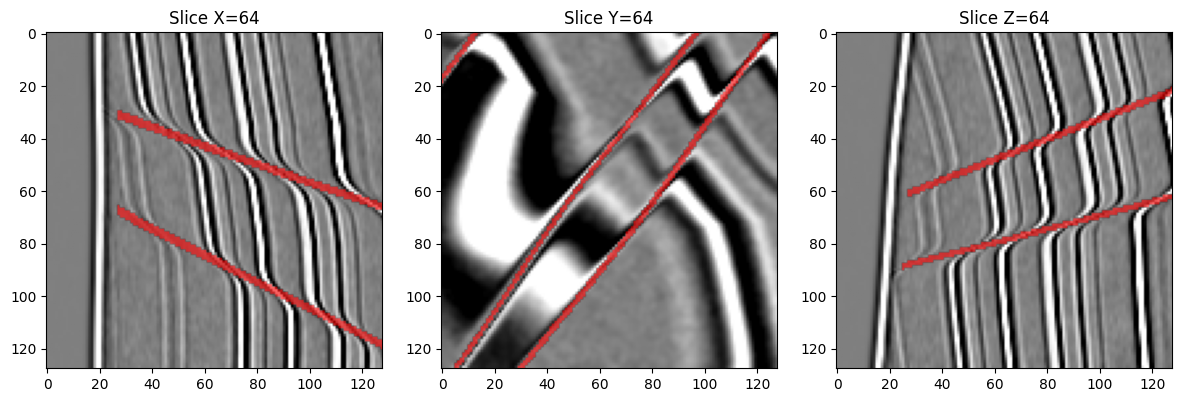

In [7]:
def showTile(img=None, mask=None, save=None):
    if img is None and mask is None:
        return print("Erro: Forneça pelo menos 'img' ou 'mask'.")

    ref_vol = img if img is not None else mask
    mid_x = ref_vol.shape[0] // 2
    mid_y = ref_vol.shape[1] // 2
    mid_z = ref_vol.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        
        s_x = np.array(vol[mid_x, :, :]) # Plano YZ
        s_y = np.array(vol[:, mid_y, :]) # Plano XZ
        s_z = np.array(vol[:, :, mid_z]) # Plano XY
        return [s_x, np.rot90(s_z, -1), s_y]

    img_slices  = get_slices(img)
    mask_slices = get_slices(mask)
    cmap_mask_only    = ListedColormap(['black', 'red', 'green', 'blue'])
    cmap_mask_overlay = ListedColormap([(0, 0, 0, 0), 'red', 'green', 'blue'])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles    = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']

    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
            
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_mask_overlay, vmin=0, vmax=3, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_mask_only, vmin=0, vmax=3)
        
        ax.set_title(titles[i])

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
        return plt.close(fig)

    plt.show()

gen = MarlimSyntheticGenerator()
img, msk = gen.get(seed=11)
showTile(img, msk)

# COMPARAÇÃO COM O BLOCO REAL
Cada região do bloco (definida em `REGIONS`) vira uma figura:

* **linha de cima**: 3 crops **reais** com a anotação do especialista em verde;
* **linha de baixo**: 3 tiles **sintéticos** da mesma banda, **pós-Format** (o que o
  modelo vê), com a máscara de falhas em vermelho.

As duas linhas estão na mesma escala [0,1] e o título mostra μ / σ / min / max da
seção exibida — os números do sintético devem cair na faixa do real da região.

In [8]:
# regiões do bloco: banda z, crops reais (pid, z0, x0) e a banda sintética (zv0)
REGIONS = {
    'fundo do mar':          {'zv0': None, 'zband': (200, 380),
                              'reals': [('1200', 240, 1300), ('1300', 250, 700), ('2600', 250, 1300)]},
    'raso (250-600)':        {'zv0': 300, 'zband': (250, 600),
                              'reals': [('1200', 300, 800), ('1300', 400, 1500), ('2600', 330, 1300)]},
    'transição (600-800)':   {'zv0': 620, 'zband': (600, 800),
                              'reals': [('1200', 560, 1300), ('1400', 650, 1600), ('2600', 700, 800)]},
    'brilhante (800-1200)':  {'zv0': 950, 'zband': (800, 1200),
                              'reals': [('1200', 1000, 800), ('1300', 950, 1400), ('2600', 1000, 1800)]},
    'morto (>1200)':         {'zv0': 1250, 'zband': (1200, 1470),
                              'reals': [('1200', 1300, 800), ('1400', 1300, 600), ('2600', 1200, 1300)]},
}


def stats(a):
    """Resumo estatístico p/ os títulos dos gráficos."""
    return f'μ={a.mean():.3f}   σ={a.std():.3f}   min={a.min():.2f}   max={a.max():.2f}'


def compareRegion(sections, name, seed0=3):
    """Uma figura desta região: crops REAIS + especialista (cima) vs tiles sintéticos
    pós-Format + máscara (baixo), ambos em [0,1] com stats comparáveis no título."""
    cfg = REGIONS[name]
    rng = np.random.RandomState(seed0)
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))

    for j, (pid, z0, x0) in enumerate(cfg['reals']):
        crop = sections[pid][z0:z0 + 128, x0:x0 + 128]
        axes[0, j].imshow(crop, cmap='gray', vmin=0, vmax=1)

        gy, gx = np.where(INTERPRETADO[pid][z0:z0 + 128, x0:x0 + 128])
        axes[0, j].scatter(gx, gy, s=0.4, c='lime', alpha=0.9)
        axes[0, j].set_title(f'REAL — patch {pid} (z={z0}, x={x0})\n{stats(crop)}', fontsize=9)

    for j in range(3):
        g    = MarlimSyntheticGenerator()
        seed = int(rng.randint(0, 1e6))

        if cfg['zv0'] is None:
            g.pWaterTile, g.pPureWater = 1.0, 0.0
            img, msk = g.get(seed=seed)
        else:
            img, msk = g.get(seed=seed, zv0=cfg['zv0'] + rng.uniform(-40, 40))

        sec, m = g.format(img[64].T), msk[64].T
        axes[1, j].imshow(sec, cmap='gray', vmin=0, vmax=1)
        if m.any():
            axes[1, j].imshow(np.ma.masked_where(m == 0, m), cmap='autumn', alpha=0.55, vmin=0, vmax=1)
        axes[1, j].set_title(f'GRvA — sintético (falha={m.mean() * 100:.1f}%)\n{stats(sec)}', fontsize=9)

    for ax in axes.ravel():
        ax.axis('off')

    fig.suptitle(f'REGIÃO: {name}', fontsize=12, y=0.99)
    plt.tight_layout(); plt.show()


def compareBands(sections, seed0=3):
    """Todas as regiões, uma figura separada por região (cada uma: 3 reais × 3 sintéticos)."""
    for i, name in enumerate(REGIONS):
        compareRegion(sections, name, seed0=seed0 + 100 * i)

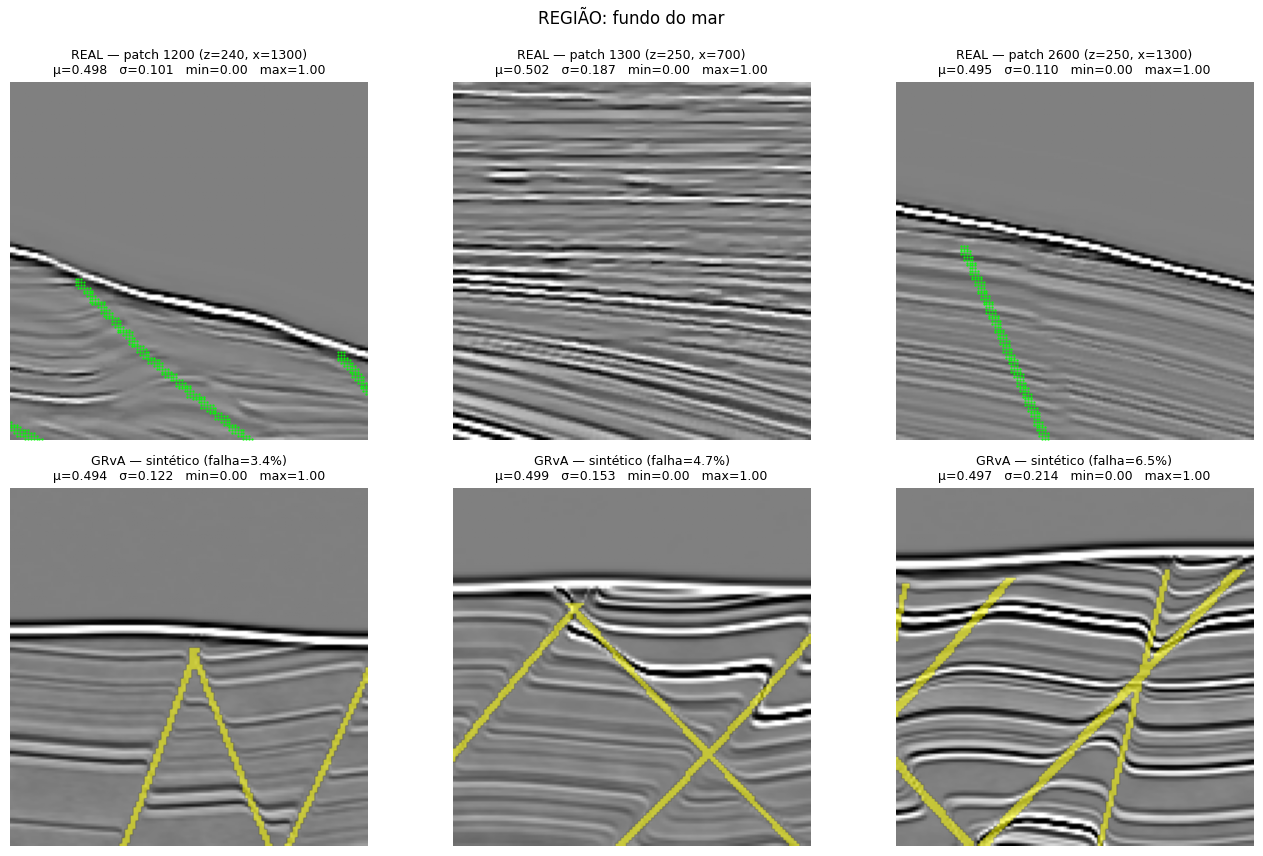

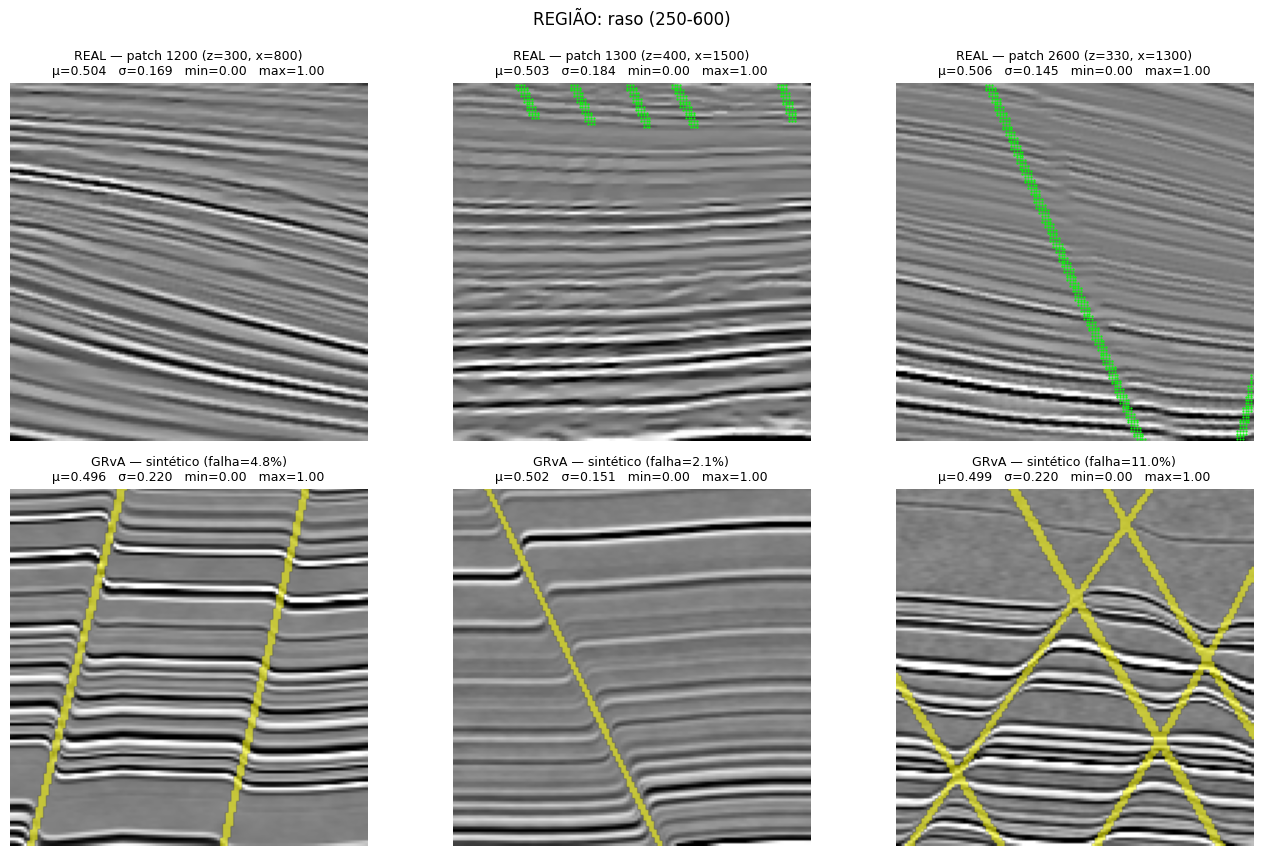

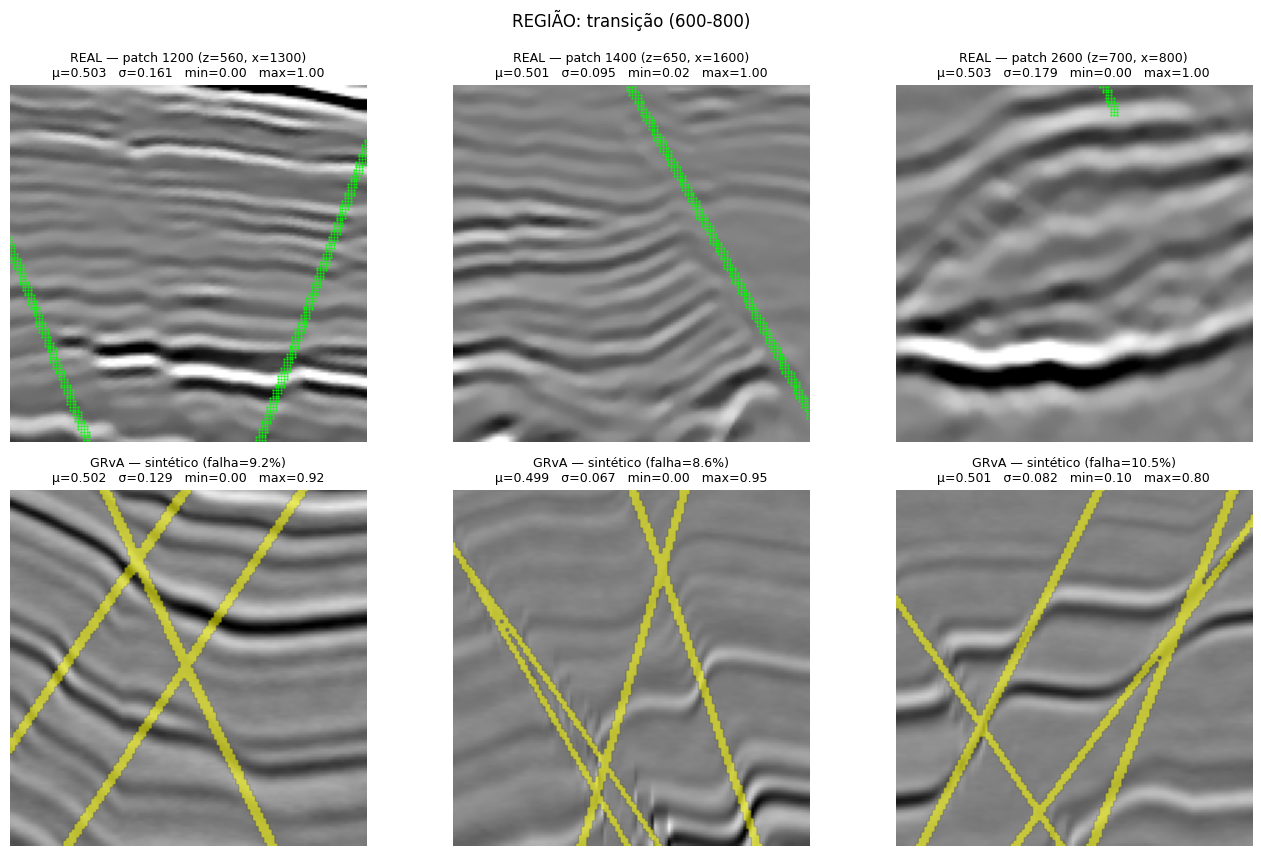

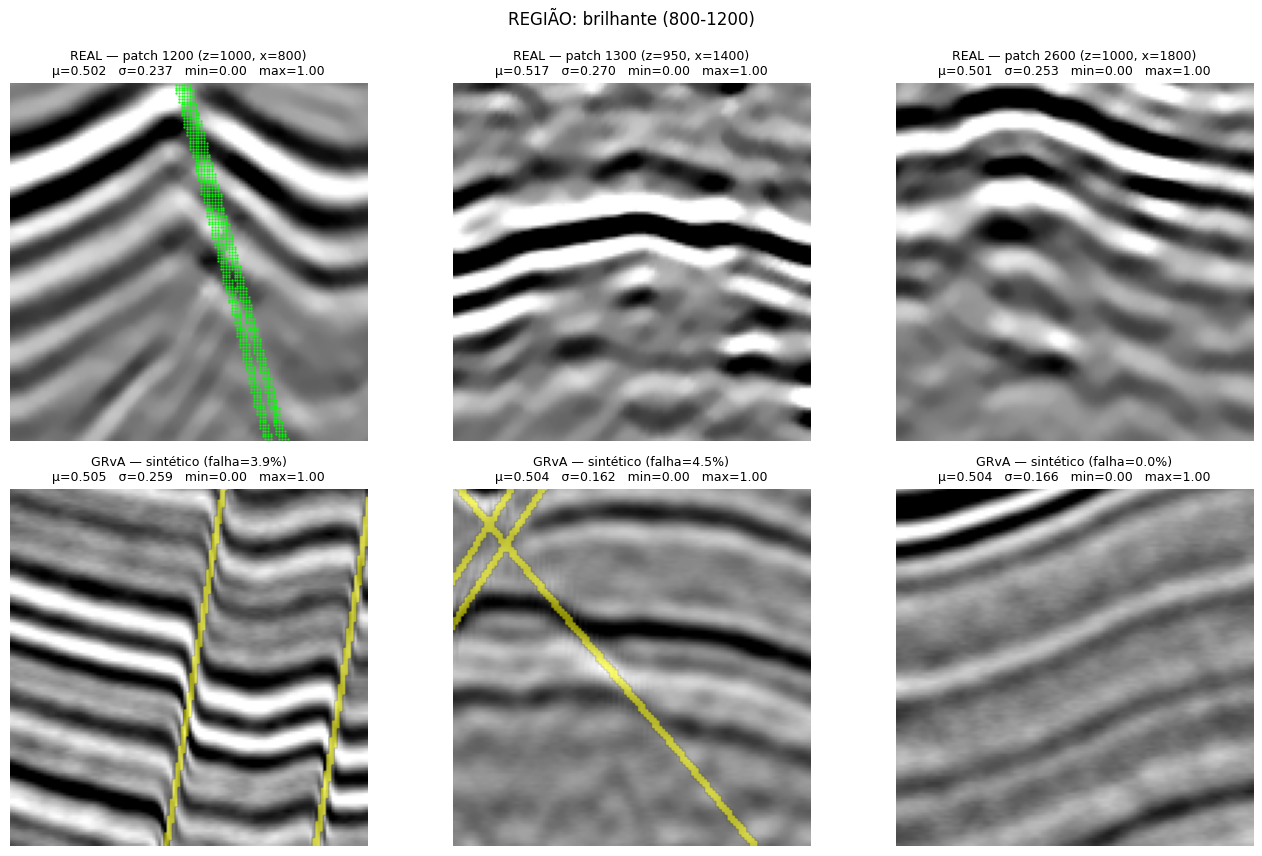

In [ ]:
compareBands(SECTIONS)

# VALIDAÇÃO
Estatísticas do sintético vs real: μ/σ/min/max por região (`validateRegions`),
contraste/máscara/geometria das falhas (`validateGenerator`) e pico do espectro
vertical por janela z (`validateSpectra`).

### VALIDANDO REGIÕES

In [ ]:
def _region_worker(args):
    seed, zv0 = args
    g = MarlimSyntheticGenerator()
    if zv0 is None:
        g.pWaterTile, g.pPureWater = 1.0, 0.0
        img, _ = g.get(seed=seed)
    else:
        img, _ = g.get(seed=seed, zv0=zv0)
    return g.format(img[64].T)


def validateRegions(sections, n=16, seed0=9000):
    """μ/σ/min/max por região (medianas): crops reais 128² vs seções sintéticas
    pós-Format. O sintético deve cair na faixa do real em cada banda."""
    ctx = mp.get_context('fork')
    stat = lambda a: np.array([a.mean(), a.std(), a.min(), a.max()])

    for name, cfg in REGIONS.items():
        zlo, zhi = cfg['zband']
        real = [stat(sec[z0:z0 + 128, x0:x0 + 128])
                for sec in sections.values()
                for z0 in range(zlo, max(zlo + 1, zhi - 127), 40)
                for x0 in range(0, 2240 - 128, 112)]

        zv0 = cfg['zv0']
        tasks = [(seed0 + 17 * i + (0 if zv0 is None else int(zv0)),
                  None if zv0 is None else zv0 + (i - n / 2) * 5.5) for i in range(n)]
        with ProcessPoolExecutor(max_workers=min(12, os.cpu_count()), mp_context=ctx) as ex:
            syn = [stat(s) for s in ex.map(_region_worker, tasks)]

        r, s = np.median(real, axis=0), np.median(syn, axis=0)
        print(f'{name:22s} real : μ={r[0]:.3f}  σ={r[1]:.3f}  min={r[2]:.2f}  max={r[3]:.2f}')
        print(f'{"":22s} synth: μ={s[0]:.3f}  σ={s[1]:.3f}  min={s[2]:.2f}  max={s[3]:.2f}')

validateRegions(SECTIONS)

### VALIDANDO GERADOR

In [ ]:
def _stat_worker(seed):
    return MarlimSyntheticGenerator().get(seed=seed)


def validateGenerator(sections, n=48, seed0=1000):
    """Contraste pós-Format, fração de máscara e geometria das falhas."""
    t0 = time.time()
    ctx = mp.get_context('fork')
    with ProcessPoolExecutor(max_workers=min(12, os.cpu_count()), mp_context=ctx) as ex:
        tiles = list(ex.map(_stat_worker, range(seed0, seed0 + n)))
    print(f'{n} tiles em {time.time()-t0:.0f}s')
    q = [5, 25, 50, 75, 95]

    # contraste por tile após o Format
    fmt = MarlimSyntheticGenerator().format(np.stack([t[0] for t in tiles]))
    synStd = fmt.reshape(n, -1).std(axis=1)

    realStd, rng = [], np.random.RandomState(0)
    for pid, sec in sections.items():
        for _ in range(120):
            z0, x0 = rng.randint(100, 1601 - 128), rng.randint(0, 2240 - 128)
            realStd.append(sec[z0:z0 + 128, x0:x0 + 128].std())
    
    print('std pós-Format  real :', np.round(np.percentile(realStd, q), 3))
    print('std pós-Format  synth:', np.round(np.percentile(synStd, q), 3))

    # fração de máscara por tile
    frac = np.array([t[1].mean() for t in tiles])
    print(f'máscara: média={frac.mean():.4f}  p90={np.percentile(frac, 90):.4f}  '
          f'sem_falha={(frac == 0).mean():.2f}')

    # geometria das falhas na seção central (dip e comprimento via PCA)
    dips, lens = [], []
    for img, msk in tiles:
        lbl, total = ndi.label(msk[64].T > 0, structure=np.ones((3, 3)))
        for i in range(1, total + 1):
            ys, xs = np.where(lbl == i)
            if len(ys) < 25:
                continue
            pts = np.stack([xs, ys]).astype(float)
            pts -= pts.mean(axis=1, keepdims=True)
            w, v = np.linalg.eigh(pts @ pts.T / len(ys))
            dips.append(np.degrees(np.arctan2(abs(v[1, -1]), abs(v[0, -1]))))
            lens.append(np.sqrt(w[-1]) * 4)

    dips, lens = np.array(dips), np.array(lens)
    print('dip synth p5..p95:', np.round(np.percentile(dips, q), 0), '| especialista: 48/61/66/72/78')
    print('len synth p5..p95:', np.round(np.percentile(lens, q), 0), f'| fração >100px: {(lens > 100).mean():.2f} (alvo ≥ ~0.75)')
    

validateGenerator(SECTIONS)

# VALIDANDO ESPECTRO

In [ ]:
def _spec_worker(args):
    seed, zv0 = args
    img, _ = MarlimSyntheticGenerator().get(seed=seed, zv0=zv0)
    x = img.reshape(-1, 128).astype(np.float64)
    x = x - x.mean(1, keepdims=True)
    return zv0, (np.abs(np.fft.rfft(x, axis=1)) ** 2).mean(0)


def validateSpectra(sections, z0s=(250, 400, 550, 700, 850, 1000, 1150, 1300), n=8, seed0=7000):
    """Pico do espectro vertical (ciclos/voxel) por janela z: real vs sintético.
    Razões fora de ~[0.85, 1.18] pedem recalibração dos freqKnots naquela profundidade."""
    freqs = np.fft.rfftfreq(128)

    def peak(P):
        i = 1 + int(np.argmax(P[1:]))
        if 1 <= i < len(P) - 1:            # refinamento parabólico do pico
            a, b, c = np.log(P[i-1] + 1e-30), np.log(P[i] + 1e-30), np.log(P[i+1] + 1e-30)
            return freqs[i] + 0.5 * (a - c) / (a - 2*b + c + 1e-30) * (freqs[1] - freqs[0])
        return freqs[i]

    tasks = [(seed0 + 53 * i + z0, float(z0)) for z0 in z0s for i in range(n)]
    ctx = mp.get_context('fork')
    with ProcessPoolExecutor(max_workers=min(16, os.cpu_count()), mp_context=ctx) as ex:
        res = list(ex.map(_spec_worker, tasks))

    for z0 in z0s:
        Pr = []
        for sec in sections.values():
            w = sec[z0:z0 + 128, :]
            keep = w.std(axis=0) > 0.03    # ignora colunas de água/zona morta
            if keep.sum() < 50:
                continue
            x = (w[:, keep] - w[:, keep].mean(0)).T.astype(np.float64)
            Pr.append((np.abs(np.fft.rfft(x, axis=1)) ** 2).mean(0))
        pr = peak(np.mean(Pr, axis=0))
        ps = peak(np.mean([P for z, P in res if z == z0], axis=0))
        print(f'z{z0:<5d} pico real={pr:.3f}  synth={ps:.3f}  razão={ps/pr:.2f}   ' f'(período {1/pr:.1f} px vs {1/ps:.1f} px)')


validateSpectra(SECTIONS)

# GERAÇÃO DO DATASET
`GENERATE = True` gera os tiles em `DATASET_DIR` (depois rode o `Format.ipynb` do dataset).

In [ ]:
GENERATE = True

if GENERATE:
    gen = MarlimSyntheticGenerator(seed=42)
    gen.dataset(n=440, outputDir=DATASET_DIR)